In [12]:
from functions import denoise_eeg, hurst_exponent, higuchi_fd, tsallis_entropy, sample_entropy
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn as F

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print(f"Using device: {device}")

Using device: cpu


Display data before movement contamination removal

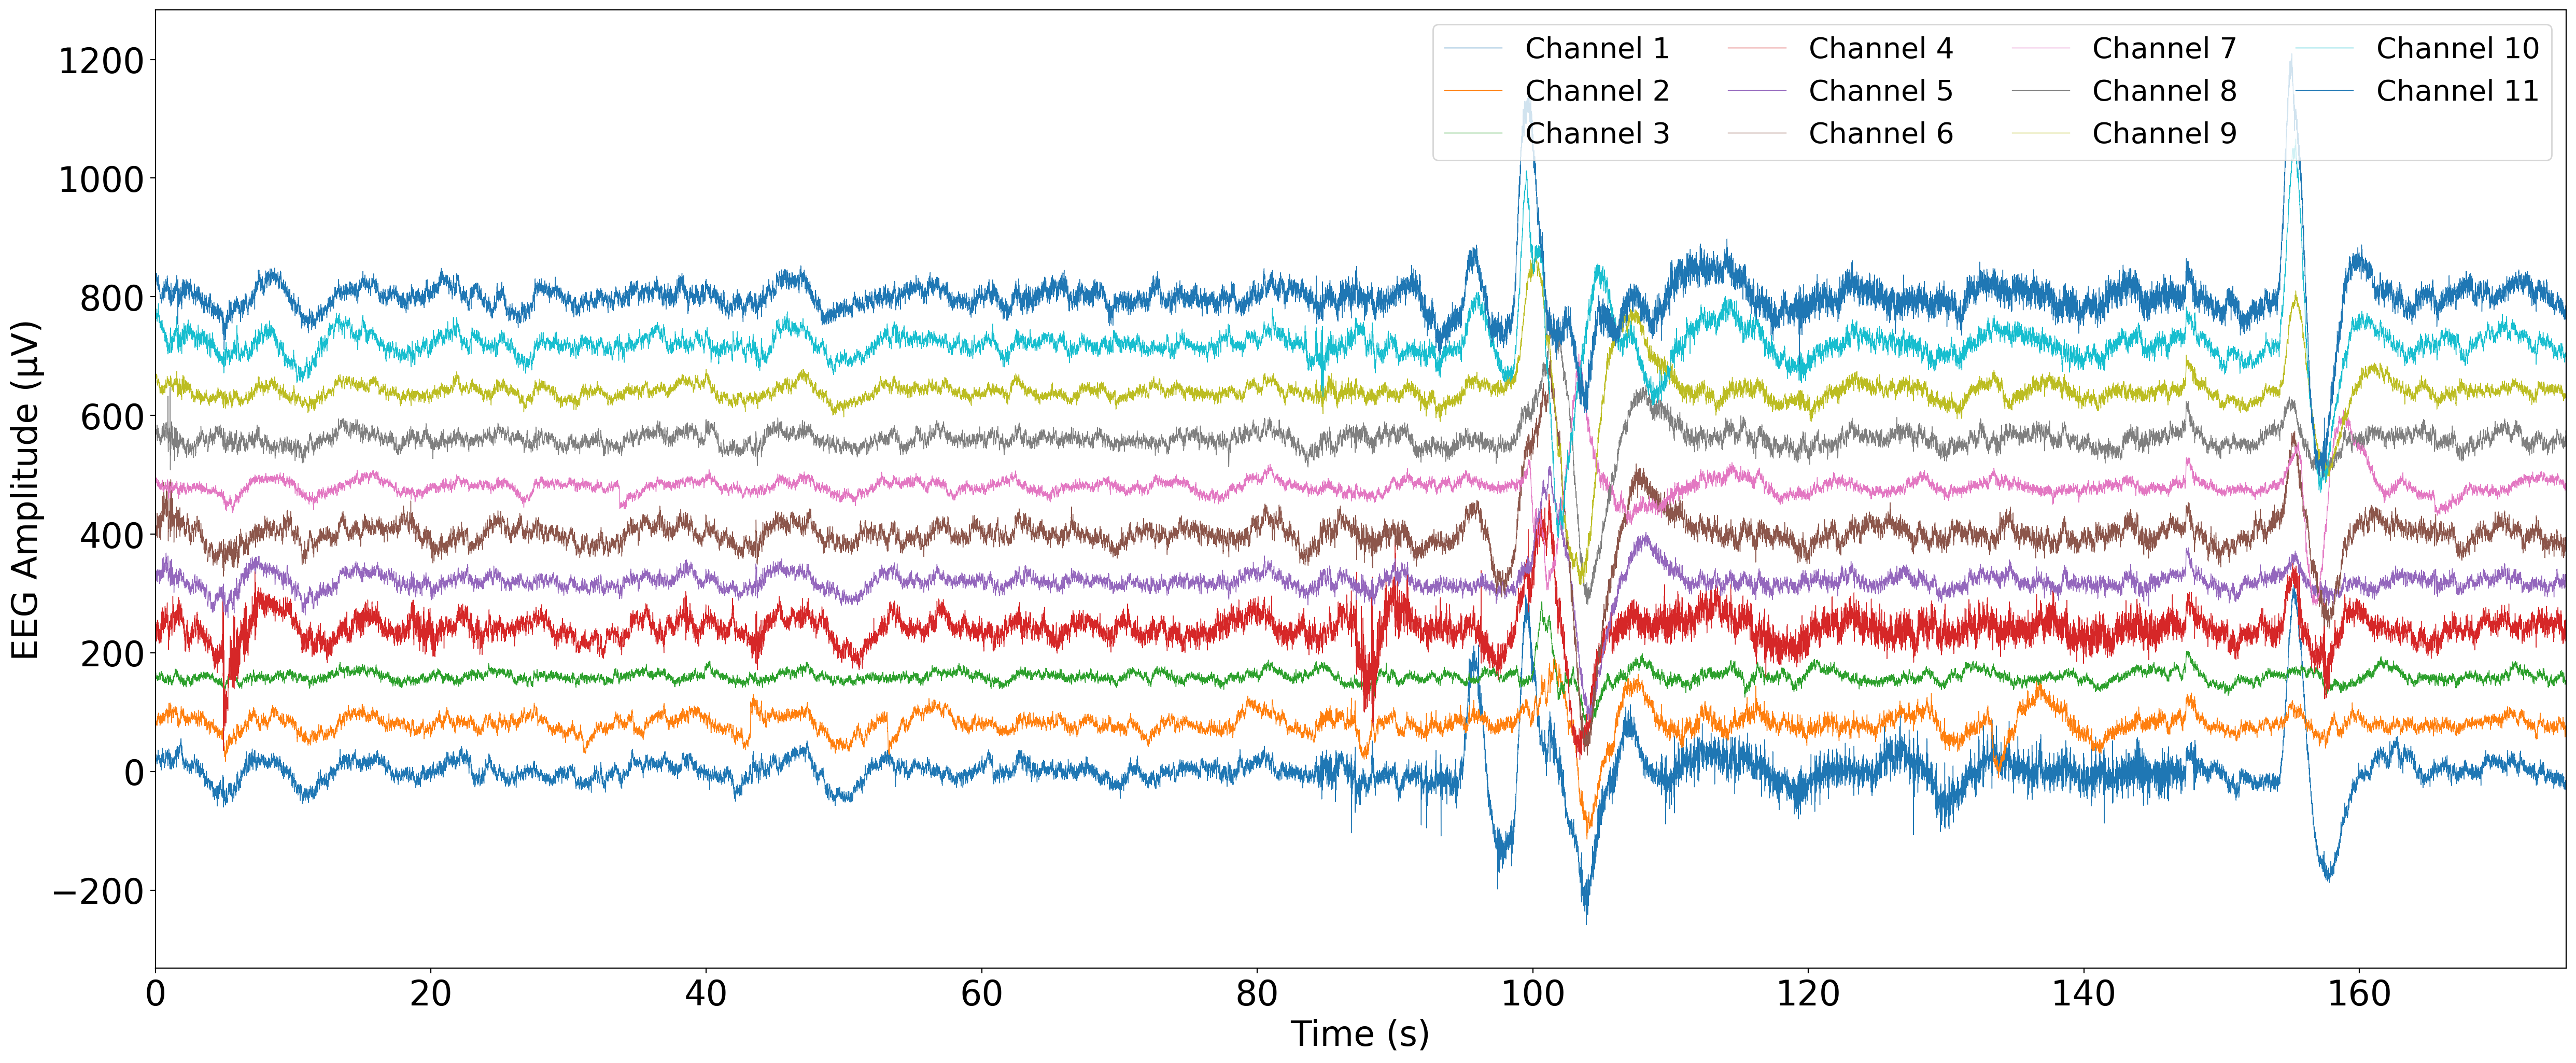

In [14]:
original_eeg_data = np.load("Processed_EEG/subject_20.npy", allow_pickle=True)

first_entry = original_eeg_data[0] 
original_eeg_signals = first_entry['data']

# Create time vector based on sample rate
sfreq = 200  # Hz, adjust if different
time = np.arange(original_eeg_signals.shape[1]) / sfreq  # Convert sample index to seconds

# Plot all 11 channels
plt.figure(figsize=(30, 12), dpi=200)
    

for i in range(original_eeg_signals.shape[0]):  # Loop over 62 channels
    plt.plot(time, original_eeg_signals[i] + i * 80, linewidth=0.5, label=f'Channel {i+1}')  
plt.xlim(time.min(), time.max())
plt.xlabel("Time (s)", fontsize=24)
plt.ylabel("EEG Amplitude (µV)", fontsize=24)
plt.tick_params(axis='both', labelsize=24)
plt.legend(loc="upper right", fontsize=20, ncol=4)  # Reduce clutter in the legend
plt.show()

In [15]:
data_dir = "Processed_EEG"
output_dir = "Processed_EEG_Output"  # Save processed files in a new directory
subjects_to_process = ['20']

# List all subject .npy files
subject_files = [f for f in os.listdir(data_dir) if f.endswith(".npy")]


for subject_file in subject_files:
        subject_id = subject_file.split('_')[-1].split('.')[0]
        
        print(subject_id)
        if subject_id in subjects_to_process:
            subject_path = os.path.join(data_dir, subject_file)
            eeg_data = np.load(subject_path, allow_pickle=True)  # Load EEG data

            print(f"Processing {subject_file}...")

            # Process all 80 emotion trials
            for trial_idx, trial in enumerate(eeg_data):  # Each trial is a dictionary {'data': array, 'label': emotion}
                video_index = trial['video_index']
                if video_index == 20:
                    eeg_signals = trial['data']  # Shape: (62, timepoints)

                    print(f"Processing Video Index: {video_index}, Trial: {trial_idx+1}")
                    for i in range(eeg_signals.shape[0]):  # Loop over 62 channels
                        eeg_signals[i], _ = denoise_eeg(eeg_signals[i])  # Apply processing
                        print(f"Subject {subject_file} - Trial {trial_idx+1} - Channel {i+1} completed")

                    trial['data'] = eeg_signals  # Update trial with processed signals

            # Save the processed subject file
            output_path = os.path.join(output_dir, subject_file)
            np.save(output_path, eeg_data)

            print(f"Saved processed data for {subject_file} to {output_path}")


20
Processing subject_20.npy...
Processing Video Index: 20, Trial: 1
Original signal: mean=0.0923414521716803, std=45.59856343785502
Final Clean Signal: mean=0.1834914018381672, std=19.963356513846076
Subject subject_20.npy - Trial 1 - Channel 1 completed
Original signal: mean=0.10821883902707681, std=23.77116227501577
Final Clean Signal: mean=0.47771019648320423, std=15.405442471444935
Subject subject_20.npy - Trial 1 - Channel 2 completed
Original signal: mean=-0.12582444324878436, std=13.131366809826078
Final Clean Signal: mean=-0.5904362070734961, std=8.7973736019948
Subject subject_20.npy - Trial 1 - Channel 3 completed
Original signal: mean=-0.16581138386677746, std=33.615328288758654
Final Clean Signal: mean=0.47950569975341684, std=20.569695082649215
Subject subject_20.npy - Trial 1 - Channel 4 completed
Original signal: mean=-0.12784980079159805, std=28.70241424172621
Final Clean Signal: mean=-0.4949389713058982, std=13.188547068849637
Subject subject_20.npy - Trial 1 - Channe

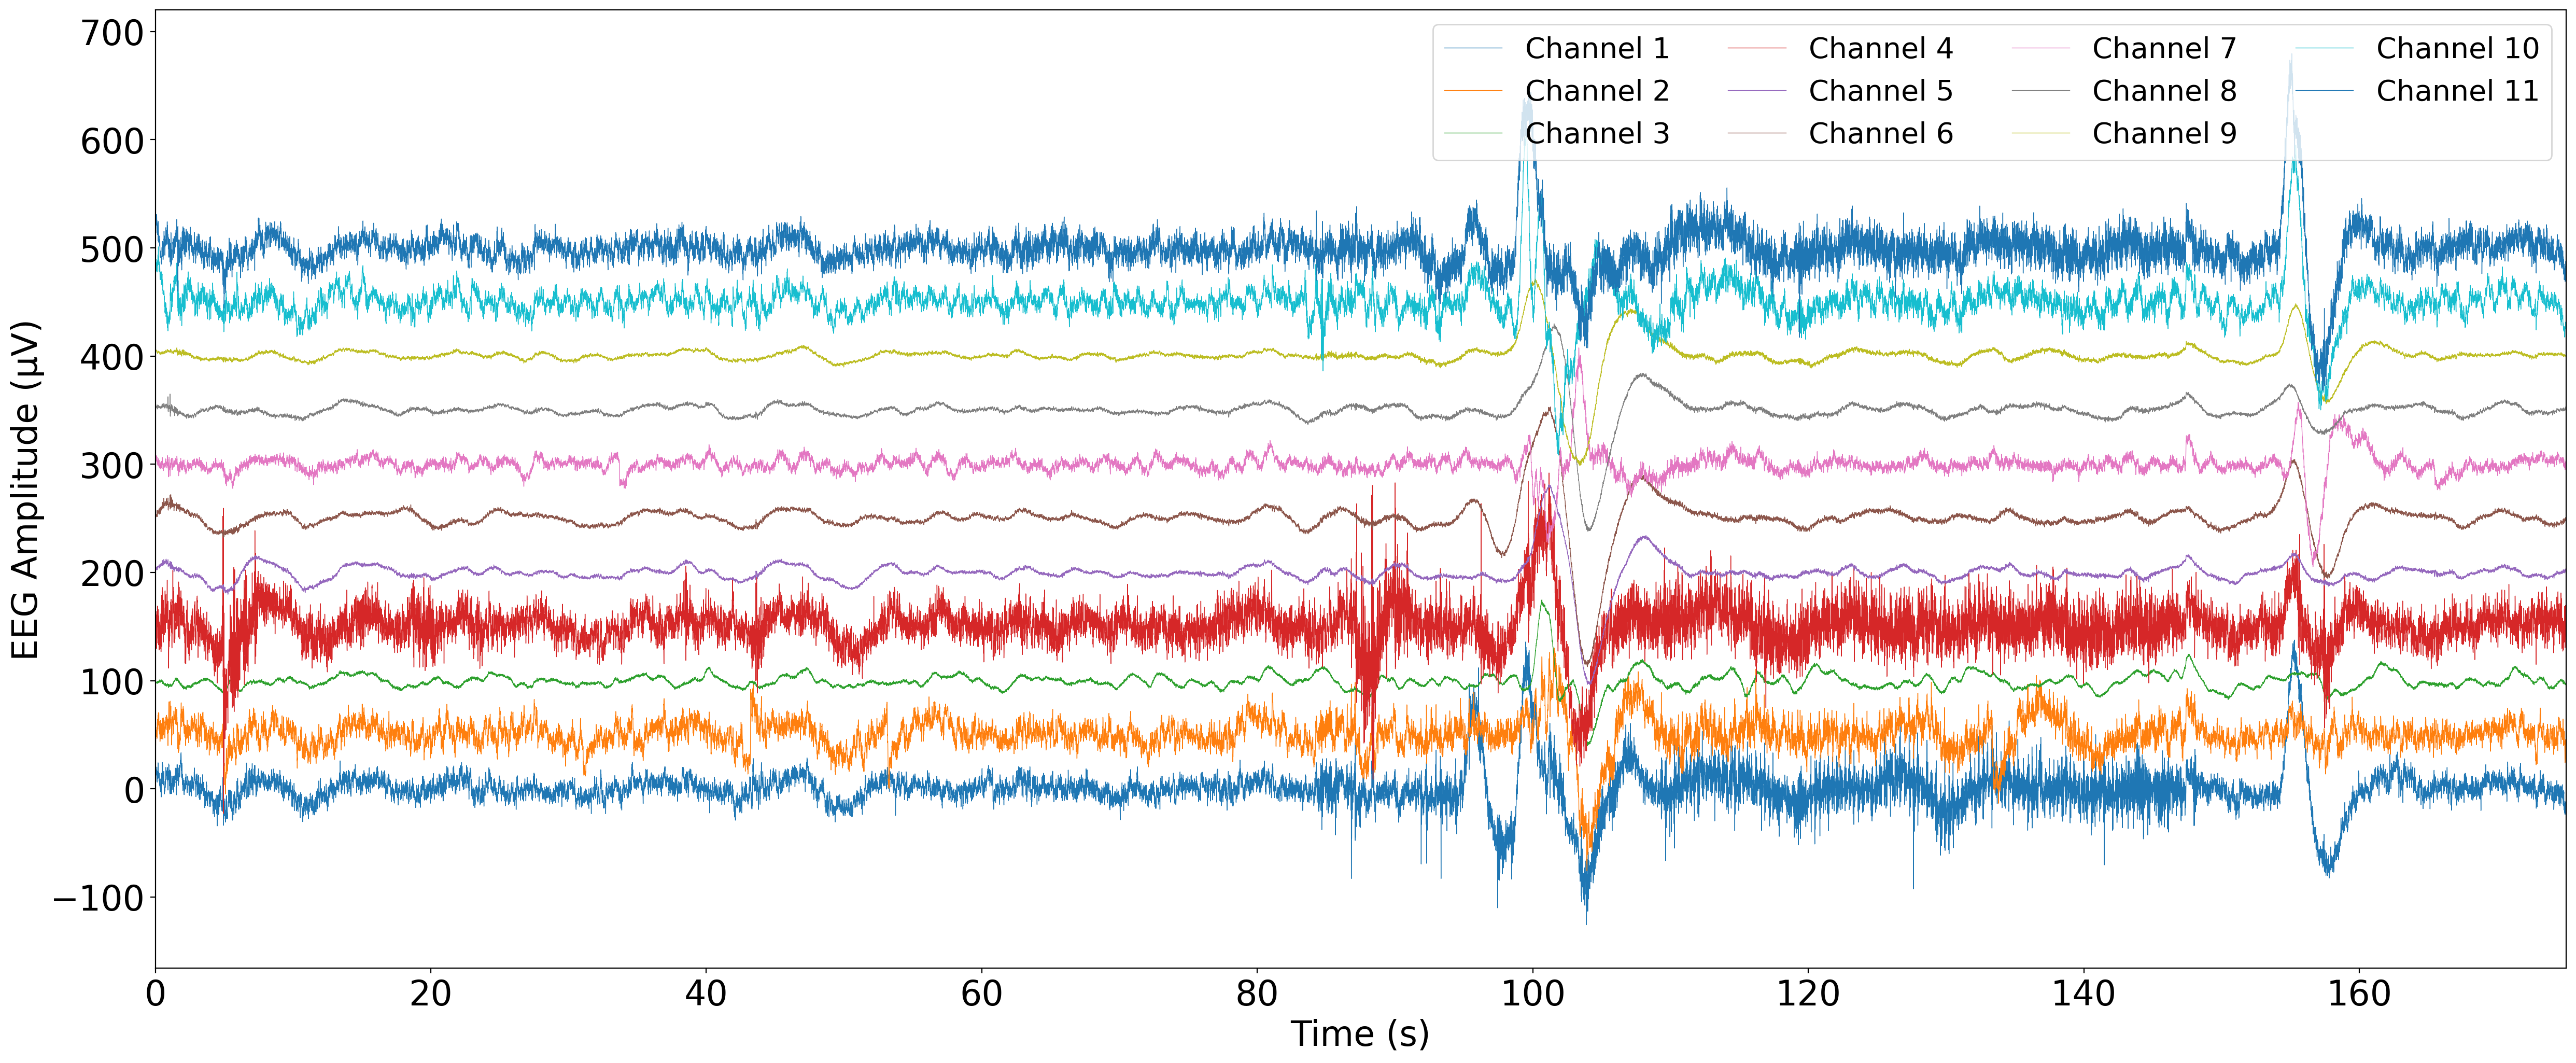

In [16]:
# Load the .npy file
original_eeg_data = np.load("Processed_EEG_Output/subject_20.npy", allow_pickle=True)  # Adjust file path as needed

# Extract time-series data from the first entry (assuming same shape for all)
first_entry = original_eeg_data[0]  # Assuming eeg_data is a list of dicts like {'data': array, 'label': emotion}
original_eeg_signals = first_entry['data']  # Shape: (62, timepoints)

# Create time vector based on sample rate
sfreq = 200  # Hz, adjust if different
time = np.arange(original_eeg_signals.shape[1]) / sfreq  # Convert sample index to seconds

# Plot all 62 channels
plt.figure(figsize=(30, 12), dpi=200)

for i in range(original_eeg_signals.shape[0]):  # Loop over 62 channels
    plt.plot(time, original_eeg_signals[i] + i * 50, linewidth=0.5, label=f'Channel {i+1}')  
    #   
    # Offset each channel vertically for visibility (scaling factor 50 can be adjusted)
plt.xlim(time.min(), time.max())
plt.xlabel("Time (s)", fontsize=24)
plt.ylabel("EEG Amplitude (µV)", fontsize=24)
plt.tick_params(axis='both', labelsize=24)
plt.legend(loc="upper right", fontsize=20, ncol=4)  # Reduce clutter in the legend
plt.show()

In [17]:
save_dir = "CIF_MATRIX"
os.makedirs(save_dir, exist_ok=True)
new_files=['20']

output_path = 'Processed_EEG_Output'

# loop through all .npy files in the folder
for file in os.listdir(output_path):
    if file.endswith('.npy'):
        subject_id = file.split('_')[-1].split('.')[0]  # Extract subject ID from filename
        print(subject_id)
        if subject_id in new_files:
            print("found")
            subject_data = np.load(os.path.join(output_path, file), allow_pickle=True)

            sampling_rate = 200  # Hz
            time_duration = 120   # seconds
            target_data_points = sampling_rate * time_duration  

            num_channels = 11 
            num_videos = len(subject_data)  # Number of trials (videos)

            # Process each video trial
            for trial_data in subject_data:
                print(trial_data['rating'])
                if trial_data['rating'] < 0.5:  # Skip if rating is too low**
                    print(f"Skipping Subject {subject_id}, Video {trial_data['video_index']} due to low rating {trial_data['rating']}")
                    continue 
                video_idx = trial_data['video_index']  # Load stored video index
                eeg_signals = trial_data['data']  # (channels, timepoints)
                print(f"Processing: Subject {subject_id}, Video {video_idx}")
                print(f"Expected label: {trial_data['label']}")

                # Extract last 60 seconds of EEG data
                sampling_rate = 200  # Hz
                time_duration = 120   # seconds
                target_data_points = sampling_rate * time_duration  
                reshaped_data = eeg_signals[:, -target_data_points:] 
                if video_idx == 20:
                    raw_segments = np.array_split(reshaped_data, 40, axis=1)
                    for segment_idx in range(40):
                        all_features = []
                        for ch1 in range(num_channels):
                                features = {
                                    "Channel": ch1,
                                    "SampleEntropy": sample_entropy(raw_segments[segment_idx][ch1, :]),
                                    "TsallisEntropy": tsallis_entropy(raw_segments[segment_idx][ch1, :]),
                                    "HiguchiFD": higuchi_fd(raw_segments[segment_idx][ch1, :]),
                                    "HurstExponent": hurst_exponent(raw_segments[segment_idx][ch1, :])
                                }
                                all_features.append(features)
                        np.save(os.path.join(save_dir, f"subject_{subject_id}_video_{video_idx}_segment_{segment_idx}_features.npy"), all_features)
                        # Also save the emotion label associated with this segment (same label for each segment in a video)
                        label_dict = {segment_idx: trial_data['label']}  # Store the same label for each segment
                        
                        # Debug: Verify label before saving
                        print(f"Saving label: {label_dict} at subject_{subject_id}_video_{video_idx}_segment_{segment_idx}_label.npy")

                        np.save(os.path.join(save_dir, f"subject_{subject_id}_video_{video_idx}_segment_{segment_idx}_label.npy"), label_dict)
                    print(f"Saved feature matrices for subject {subject_id}, trial {video_idx}")
                print(f"Saved feature matrices for subject {subject_id}")

20
found
0.5
Processing: Subject 20, Video 20
Expected label: Happy
Saving label: {0: 'Happy'} at subject_20_video_20_segment_0_label.npy
Saving label: {1: 'Happy'} at subject_20_video_20_segment_1_label.npy
Saving label: {2: 'Happy'} at subject_20_video_20_segment_2_label.npy
Saving label: {3: 'Happy'} at subject_20_video_20_segment_3_label.npy
Saving label: {4: 'Happy'} at subject_20_video_20_segment_4_label.npy
Saving label: {5: 'Happy'} at subject_20_video_20_segment_5_label.npy
Saving label: {6: 'Happy'} at subject_20_video_20_segment_6_label.npy
Saving label: {7: 'Happy'} at subject_20_video_20_segment_7_label.npy
Saving label: {8: 'Happy'} at subject_20_video_20_segment_8_label.npy
Saving label: {9: 'Happy'} at subject_20_video_20_segment_9_label.npy
Saving label: {10: 'Happy'} at subject_20_video_20_segment_10_label.npy
Saving label: {11: 'Happy'} at subject_20_video_20_segment_11_label.npy
Saving label: {12: 'Happy'} at subject_20_video_20_segment_12_label.npy
Saving label: {1

In [ ]:
class EEG_CNN(nn.Module):
    def __init__(self, num_classes=7, num_conv_layers=3, filters=16, fc_size=128, input_size=4, input_channels=11):
        super(EEG_CNN, self).__init__()
        original_filters= filters
        layers = []
        in_channels = 1  # Input channels for EEG PCC matrices
        current_size = input_size  # Track feature map size
        current_channels = input_channels
        for i in range(num_conv_layers):
            layers.append(nn.Conv2d(in_channels, filters, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(filters))
            layers.append(nn.LeakyReLU(0.1))
            layers.append(nn.MaxPool2d(kernel_size=2, stride=1))
            in_channels = filters  # Update for next layer
            
            if i == 2:
                layers.append(nn.Dropout(0.015))
            current_size = current_size - 1  # Each pooling reduces size by 1 (stride=1, kernel_size=2)
            current_channels = current_channels - 1
            filters = filters * 2
        
        self.conv_layers = nn.Sequential(*layers)
        # Compute dynamically the input size for fc1
        last_filters = original_filters * (2 ** (num_conv_layers - 1))
        
        # Compute correct input size for fc1 dynamically
        flattened_size = last_filters * current_size * current_channels
        self.fc1 = nn.Linear(flattened_size, fc_size)  # Adjust shape based on pooling
        self.fc2 = nn.Linear(fc_size, num_classes)
    
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Load in Pre-trained Model

In [ ]:
# Reinitialize model architecture
loaded_model = EEG_CNN(num_classes=7, num_conv_layers=3, filters=32, fc_size=128).to(device)  # Make sure the architecture matches
loaded_model.load_state_dict(torch.load("eeg_model.pth"))
loaded_model.eval()  # Set to evaluation mode

# Move to the correct device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model.to(device)

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

Prepare data to go into model

In [ ]:
subject_data = np.load("CIF_MATRIX/subject_20_video_20_segment_30_features.npy",allow_pickle=True)
label_mapping = {
            'Happy': 0,
            'Surprise': 1,
            'Disgust': 2,
            'Fear': 3,
            'Anger': 4,
            'Sad': 5,
            'Neutral': 6
        }

feature_vector = []

# Loop through each channel's features and extract the 4 features
for channel_features in subject_data:
    # Extract the 4 features per channel
    channel_data = [
        channel_features["SampleEntropy"],
        channel_features["TsallisEntropy"],
        channel_features["HiguchiFD"],
        channel_features["HurstExponent"]
    ]

    # Append to the feature vector
    feature_vector.append(channel_data)

feature_vector = np.array(feature_vector, dtype=np.float32)
X = torch.tensor(feature_vector, dtype=torch.float32)
X = X.unsqueeze(0)  # Add batch dimension (1, 11, 1, 4)
X = X.to(device)
with torch.no_grad():  # Disable gradient calculation during inference
    output = loaded_model(X)

Get Model Predicted emotion

In [ ]:
probabilities = torch.softmax(output, dim=1)
predicted_class_idx = torch.argmax(probabilities, dim=1).item()  # Get the class index (scalar)
reverse_label_mapping = {v: k for k, v in label_mapping.items()}
predicted_emotion = reverse_label_mapping.get(predicted_class_idx, "Unknown")

# Print the predicted emotion
print(f"Predicted emotion: {predicted_emotion}")

NameError: name 'output' is not defined